# Medical Insurance Cost Prediction

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


# Generate random ensurance.csv data 

In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of records
n = 1338   # same size as real dataset

# Generate realistic synthetic data
age = np.random.randint(18, 65, n)
sex = np.random.choice(['male', 'female'], n)
bmi = np.round(np.random.normal(30, 6, n), 1)
children = np.random.randint(0, 5, n)
smoker = np.random.choice(['yes', 'no'], n, p=[0.2, 0.8])
region = np.random.choice(['southeast', 'southwest', 'northeast', 'northwest'], n)

# Generate charges using realistic model
charges = (
    200 +
    age * 250 +
    bmi * 350 +
    children * 500 +
    np.where(sex == 'male', 700, 0) +
    np.where(smoker == 'yes', 20000, 0) +
    np.random.normal(0, 3000, n)
)

df = pd.DataFrame({
    'age': age,
    'sex': sex,
    'bmi': bmi,
    'children': children,
    'smoker': smoker,
    'region': region,
    'charges': np.round(charges, 2)
})

# Save dataset
df.to_csv("insurance.csv", index=False)

df.head()


,age,sex,bmi,children,smoker,region,charges
0,56,male,26.5,4,yes,southwest,45041.23
1,46,female,28.8,3,no,northwest,21034.07
2,32,male,25.4,4,yes,northwest,40597.07
3,60,male,30.2,2,no,southwest,28602.89
4,25,male,26.3,1,no,southwest,19330.06


# Load Dataset & Basic Checks

In [3]:
df = pd.read_csv("insurance.csv")
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,29.834380,2.076981,26440.634410
std,13.528861,5.914189,1.389961,9449.842353
min,18.000000,9.200000,0.000000,7311.550000
25%,29.000000,25.800000,1.000000,19838.610000
50%,42.000000,30.000000,2.000000,24075.155000
75%,52.000000,33.875000,3.000000,30511.752500
max,64.000000,46.400000,4.000000,53767.550000


# Exploratory Data Analysis (EDA)

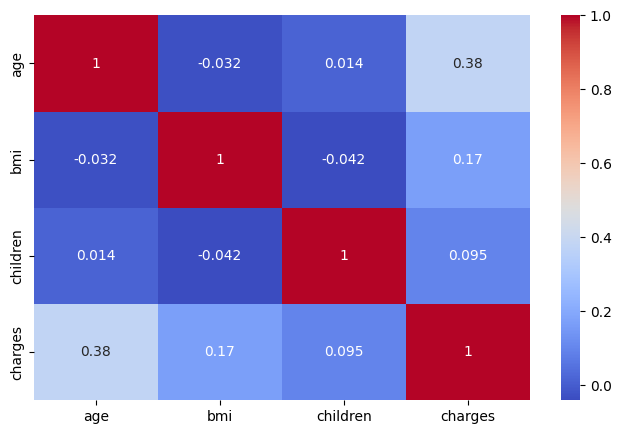

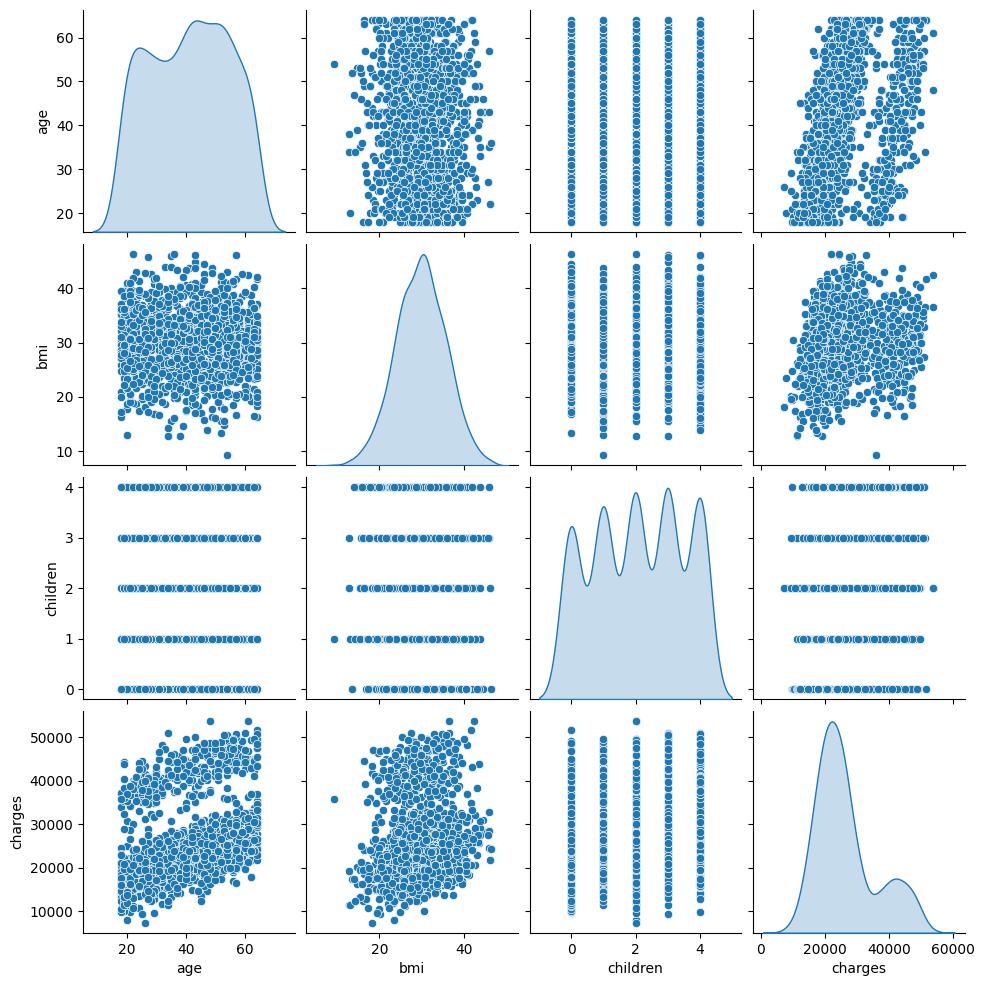

In [7]:
# Correlation heatmap (use only numeric columns)
plt.figure(figsize=(8,5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Pairplot for numeric columns only to avoid conversion errors from categorical strings
sns.pairplot(numeric_df, diag_kind='kde')
plt.show()


# One-Hot Encoding + Preprocessing

In [8]:
df_enc = pd.get_dummies(df, drop_first=True)

X = df_enc.drop("charges", axis=1)
y = df_enc["charges"]


# Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# Train Linear, Ridge, and Lasso Models

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.001)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)


,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# Evaluate Models

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": lr,
    "Ridge Regression": ridge,
    "Lasso Regression": lasso
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R² Score:", r2)



Linear Regression
RMSE: 3152.9753293630374
R² Score: 0.8827311488287309

Ridge Regression
RMSE: 3151.810806662878
R² Score: 0.8828177571944418

Lasso Regression
RMSE: 3152.975130817953
R² Score: 0.8827311635977353


# Mathematical Regression Model

In [13]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coeff_df


,Feature,Coefficient
0,age,3424.276785
1,bmi,2092.069154
2,children,851.336790
3,sex_male,253.908124
4,smoker_yes,8053.646863
5,region_northwest,202.377401
6,region_southeast,106.707112
7,region_southwest,124.272127


# Residual Plot

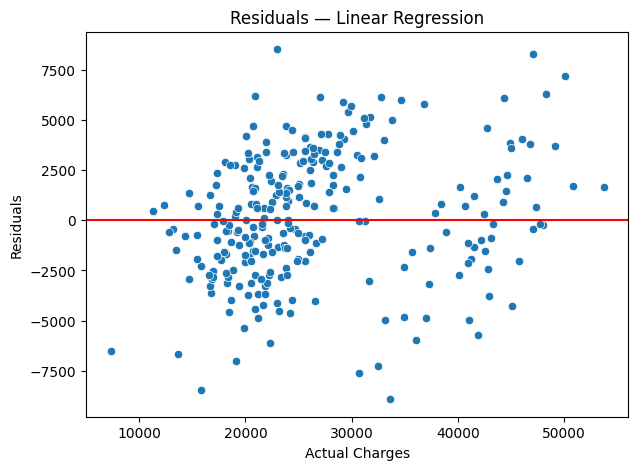

In [14]:
y_pred_lr = lr.predict(X_test)

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_test - y_pred_lr)
plt.axhline(0, color='red')
plt.xlabel("Actual Charges")
plt.ylabel("Residuals")
plt.title("Residuals — Linear Regression")
plt.show()


# Test Model with Custom Example

In [16]:
sample = pd.DataFrame({
    'age': [40],
    'bmi': [28],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [1],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

sample_scaled = scaler.transform(sample)

predicted = lr.predict(sample_scaled)
print("Predicted Insurance Charges =", predicted[0])


Predicted Insurance Charges = 41598.93897869309
